In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/pm25_daily_dc_md.csv", parse_dates=["date"])
df.head()


,State Name,County Name,Site Num,Latitude,Longitude,Arithmetic Mean,Units of Measure,Sample Duration,Observation Count,source_file,date
0,District Of Columbia,District of Columbia,41,38.895572,-76.958072,7.625000,Micrograms/cubic meter (LC),1 HOUR,24,daily_88101_2018.csv,2018-01-01
1,District Of Columbia,District of Columbia,41,38.895572,-76.958072,9.625000,Micrograms/cubic meter (LC),1 HOUR,24,daily_88101_2018.csv,2018-01-02
2,District Of Columbia,District of Columbia,41,38.895572,-76.958072,17.041667,Micrograms/cubic meter (LC),1 HOUR,24,daily_88101_2018.csv,2018-01-03
3,District Of Columbia,District of Columbia,41,38.895572,-76.958072,8.250000,Micrograms/cubic meter (LC),1 HOUR,24,daily_88101_2018.csv,2018-01-04
4,District Of Columbia,District of Columbia,41,38.895572,-76.958072,2.416667,Micrograms/cubic meter (LC),1 HOUR,24,daily_88101_2018.csv,2018-01-05


In [3]:
print("Rows:", len(df))
print("Date range:", df["date"].min(), "to", df["date"].max())
print("States:", df["State Name"].unique())
print("Counties:", df["County Name"].nunique())
print("Sites:", df["Site Num"].nunique())
print("Units:", df["Units of Measure"].unique())
print("Sample durations:", df["Sample Duration"].unique())


Rows: 33723
Date range: 2018-01-01 00:00:00 to 2024-12-31 00:00:00
States: ['District Of Columbia' 'Maryland']
Counties: 12
Sites: 16
Units: ['Micrograms/cubic meter (LC)']
Sample durations: ['1 HOUR' '24-HR BLK AVG' '24 HOUR']


In [7]:
df["Arithmetic Mean"].describe()
df.isna().mean().sort_values(ascending=False).head(15)

State Name           0.0
County Name          0.0
Site Num             0.0
Latitude             0.0
Longitude            0.0
Arithmetic Mean      0.0
Units of Measure     0.0
Sample Duration      0.0
Observation Count    0.0
source_file          0.0
date                 0.0
dtype: float64

Text(0, 0.5, 'PM2.5 (micrograms/m^3)')

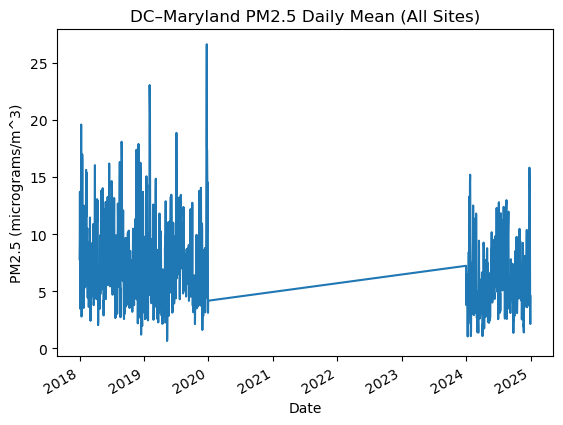

In [9]:
daily_mean = df.groupby("date")["Arithmetic Mean"].mean()

ax = daily_mean.plot(title="DC–Maryland PM2.5 Daily Mean (All Sites)")
ax.set_xlabel("Date")
ax.set_ylabel("PM2.5 (micrograms/m^3)")


Text(0, 0.5, 'PM2.5 (micrograms/m^3)')

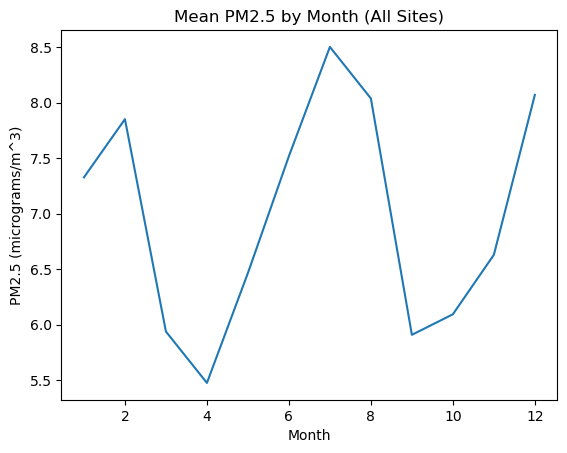

In [13]:
df["month"] = df["date"].dt.month
month_stats = df.groupby("month")["Arithmetic Mean"].agg(["mean","median","count"])

ax = month_stats["mean"].plot(title="Mean PM2.5 by Month (All Sites)")
ax.set_xlabel("Month")
ax.set_ylabel("PM2.5 (micrograms/m^3)")


“Sanity-check findings”
Data covers expected years (confirm)
#sites seems reasonable
Units are LC micrograms/m^3